# Credit Risk Analytics Pipeline
### Business Problem

Financial institutions issue thousands of credit cards every year, but not every customer repays their dues on time. Customer defaults can result in significant financial losses and increase the overall credit risk for the bank.

The objective of this project is to analyze customer demographics, credit usage patterns, repayment behavior, and historical payment records to identify the key factors associated with credit default. The insights generated from this analysis can help financial institutions improve risk assessment, optimize lending decisions, and proactively identify high-risk customers.

### Project Objectives
- Perform data inspection and quality assessment.
Clean and validate the dataset.
- Engineer meaningful business features related to credit utilization and repayment behavior.
- Conduct exploratory data analysis (EDA) to uncover customer spending and payment patterns.
- Analyze factors influencing credit default.
- Generate business KPIs and actionable insights.
- Prepare a cleaned dataset for dashboarding and predictive modeling.


 ### Import required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1) Data Loading & Quality Assesment


### Load Dataset
The dataset is loaded into a panda DataFrame for further analysis

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")


### Display first five records

Inspect the first few observations to understand the dataset structure.

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Dataset dimensions

Understanding the number of observations and features

In [4]:
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns")

The dataset has 30000 rows and 25 columns


## Dataset Information

This section provides:

- Column names
- Data types
- Non-null values
- Memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

### Observation

- All variables are stored as numeric data types
- The dataset contains 30,000 non null values indicating that  there are no missing values.



## Statistical Summary

Summary statistics provide an overview of numerical features including:

- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### Observation
- The customer age ranges from young adults to senior individuals.
- Credit limits vary significantly, indicating customers with different borrowing capacities.
- Monthly bill amounts and payment amounts exhibit considerable variation.
- Some variables contain negative values, which will be examined during the data validation stage to determine whether they represent valid business scenarios or data quality issues.

## Duplicate Record Analysis

Duplicate observations can introduce bias into the analysis.

This step checks whether duplicate rows exist in the dataset.

In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")


Duplicate Rows: 0


## Unique Values

Understanding feature cardinality helps distinguish categorical and numerical variables.

In [8]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,ID,30000
1,LIMIT_BAL,81
2,SEX,2
3,EDUCATION,7
4,MARRIAGE,4
5,AGE,56
6,PAY_0,11
7,PAY_2,11
8,PAY_3,11
9,PAY_4,11


### Observation

The dataset contains a combinatin of identifier, demographic variables, Repayment history variables, Bill amount Variables, Payment amount variables and target variables.


# Data Cleaning & ETL

The purpose of this section is to prepare the dataset for exploratory analysis and dashboard development.

Cleaning tasks performed:

- Create a working copy of the dataset
- Rename columns
- Remove duplicate records
- Validate missing values
- Convert encoded categorical variables
- Validate numerical features
- Detect outliers
- Save cleaned dataset

## Create Working Copy

Create a copy of original dataframe


In [9]:
credit_df = df.copy()


## Rename Columns

In [10]:
credit_df.rename(columns={
    "ID": "customer_id",
    "LIMIT_BAL": "credit_limit",
    "SEX": "gender",
    "EDUCATION": "education",
    "MARRIAGE": "marital_status",
    "AGE": "age",
     "PAY_0":"Sep_Payment_Status",
    "PAY_2":"Aug_Payment_Status",
    "PAY_3":"Jul_Payment_Status",
    "PAY_4":"Jun_Payment_Status",
    "PAY_5":"May_Payment_Status",
    "PAY_6":"Apr_Payment_Status",
    "BILL_AMT1":"Sep_Bill",
    "BILL_AMT2":"Aug_Bill",
    "BILL_AMT3":"Jul_Bill",
    "BILL_AMT4":"Jun_Bill",
    "BILL_AMT5":"May_Bill",
    "BILL_AMT6":"Apr_Bill",
    "PAY_AMT1":"Sep_Payment",
    "PAY_AMT2":"Aug_Payment",
    "PAY_AMT3":"Jul_Payment",
    "PAY_AMT4":"Jun_Payment",
    "PAY_AMT5":"May_Payment",
    "PAY_AMT6":"Apr_Payment",
    "default.payment.next.month":"Default"
}, inplace=True)



### Missing and Duplicate Value Analysis

The dataset was checked for missing and duplicate observations

**Observation**

- No missing values and duplicate records were identified.
- Therefore, no imputation techniques and duplicate removal were required.

## Convert Gender

In [11]:
credit_df["gender"] = credit_df["gender"].replace({
    1: "Male",
    2: "Female"
})
credit_df["gender"].value_counts()

,count
gender,
Female,18112
Male,11888


## Convert Education

In [12]:
education_map = {
    1:"Graduate School",
    2:"University",
    3:"High School",
    4:"Others",
    0:"Unknown",
    5:"Unknown",
    6:"Unknown"
}

credit_df["education"] = credit_df["education"].replace(education_map)
credit_df["education"].value_counts()

,count
education,
University,14030
Graduate School,10585
High School,4917
Unknown,345
Others,123


## Convert Marital Status

In [13]:
marital_map = {
    1:"Married",
    2:"Single",
    3:"Others",
    0:"Unknown"
}

credit_df["marital_status"] = credit_df["marital_status"].replace(marital_map)
credit_df["marital_status"].value_counts()

,count
marital_status,
Single,15964
Married,13659
Others,323
Unknown,54


### Convert Default Column

In [14]:
credit_df["Default"] = credit_df["Default"].replace({
    0:"No",
    1:"Yes"
})

### Validate Age

In [15]:
credit_df["age"].describe()

,age
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


In [16]:
credit_df[(credit_df["age"]<18) | (credit_df["age"]>100)]

,customer_id,credit_limit,gender,education,marital_status,age,Sep_Payment_Status,Aug_Payment_Status,Jul_Payment_Status,Jun_Payment_Status,...,Jun_Bill,May_Bill,Apr_Bill,Sep_Payment,Aug_Payment,Jul_Payment,Jun_Payment,May_Payment,Apr_Payment,Default


Observation:

No unrealistic ages were found

### Validate Credit Limit

In [17]:

credit_df["credit_limit"].describe()
credit_df[credit_df["credit_limit"]<0]

,customer_id,credit_limit,gender,education,marital_status,age,Sep_Payment_Status,Aug_Payment_Status,Jul_Payment_Status,Jun_Payment_Status,...,Jun_Bill,May_Bill,Apr_Bill,Sep_Payment,Aug_Payment,Jul_Payment,Jun_Payment,May_Payment,Apr_Payment,Default


# Validate Bill amounts

In [18]:
bill_columns = [
    "Sep_Bill",
    "Aug_Bill",
    "Jul_Bill",
    "Jun_Bill",
    "May_Bill",
    "Apr_Bill"
]

credit_df[bill_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sep_Bill,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
Aug_Bill,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
Jul_Bill,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
Jun_Bill,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
May_Bill,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
Apr_Bill,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


## Validate Payment Amounts

In [19]:
payment_columns = [
    "Sep_Payment",
    "Aug_Payment",
    "Jul_Payment",
    "Jun_Payment",
    "May_Payment",
    "Apr_Payment"
]

credit_df[payment_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sep_Payment,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
Aug_Payment,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
Jul_Payment,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
Jun_Payment,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
May_Payment,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
Apr_Payment,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


Check for negative payments

In [20]:
for col in payment_columns:
    print(col, (credit_df[col] < 0).sum())

Sep_Payment 0
Aug_Payment 0
Jul_Payment 0
Jun_Payment 0
May_Payment 0
Apr_Payment 0


In [21]:
numeric_cols = [
    "credit_limit","age",
    "Sep_Bill","Aug_Bill","Jul_Bill",
    "Jun_Bill","May_Bill","Apr_Bill",
    "Sep_Payment","Aug_Payment","Jul_Payment",
    "Jun_Payment","May_Payment","Apr_Payment"
]

for col in numeric_cols:
    Q1 = credit_df[col].quantile(0.25)
    Q3 = credit_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((credit_df[col] < lower) | (credit_df[col] > upper)).sum()

    print(f"{col}: {outliers}")

credit_limit: 167
age: 272
Sep_Bill: 2400
Aug_Bill: 2395
Jul_Bill: 2469
Jun_Bill: 2622
May_Bill: 2725
Apr_Bill: 2693
Sep_Payment: 2745
Aug_Payment: 2714
Jul_Payment: 2598
Jun_Payment: 2994
May_Payment: 2945
Apr_Payment: 2958


### Observation

The IQR method flagged several observations as statistical outliers. However, after considering the buisness context, i concluded that these represents genuine value. Customers with high credit limits, large bills or substanial payments are common in banking and are often the most informative for credit risk analysis.

## Save Clean Dataset

In [22]:
credit_df.to_csv(
    "clean_credit_data.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


# Feature Engineering

## Objective

Feature engineering involves creating new variables from existing data to improve business analysis and generate meaningful insights.

The engineered features will help answer questions such as:

- Which customers have high credit utilization?
- Who has a poor payment history?
- Which age group has the highest default rate?
- How much does each customer owe on average?
- How much does each customer pay on average?



### Creating Age Groups
Customers are segmented into age groups to simplify demographic analysis and identify which age segments contribute most to credit defaults.

In [23]:
credit_df["Age_Group"] = pd.cut(
    credit_df["age"],
    bins=[20,30,40,50,60,80],
    labels=[
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61+"
    ]
)
credit_df["Age_Group"].value_counts().sort_index()

,count
Age_Group,
21-30,11013
31-40,10713
41-50,6005
51-60,1997
61+,272


### Total Bill Amount

The total outstanding bill amount is calculated by summing bill statements across six months.

In [24]:
bill_columns = [
    "Sep_Bill",
    "Aug_Bill",
    "Jul_Bill",
    "Jun_Bill",
    "May_Bill",
    "Apr_Bill"
]

credit_df["Total_Bill"] = credit_df[bill_columns].sum(axis=1)
print(credit_df["Total_Bill"])

0          7704.0
1         17077.0
2        101653.0
3        231334.0
4        109339.0
           ...   
29995    725349.0
29996     21182.0
29997     70496.0
29998    266611.0
29999    230874.0
Name: Total_Bill, Length: 30000, dtype: float64


## Total Payment Amount

Total payment made by each customer over six months.

In [25]:
payment_columns = [
    "Sep_Payment",
    "Aug_Payment",
    "Jul_Payment",
    "Jun_Payment",
    "May_Payment",
    "Apr_Payment"
]

credit_df["Total_Payment"] = credit_df[payment_columns].sum(axis=1)

## Average Bill

In [26]:
credit_df["Average_Bill"] = (
    credit_df["Total_Bill"] / 6
)

## Average Payment

In [27]:
credit_df["Average_Payment"] = (
    credit_df["Total_Payment"] / 6
)

## Credit Utilization Ratio

Credit Utilization measures the proportion of the available credit limit currently being used.

Higher utilization generally indicates increased financial risk.

In [28]:
credit_df["Credit_Utilization"] = (
    credit_df["Total_Bill"] /
    credit_df["credit_limit"]
).round(2)

## Payment Ratio
Measures how much of the outstanding balance is being paid.


In [29]:
credit_df["Payment_Ratio"] = (
    credit_df["Total_Payment"] /
    credit_df["Total_Bill"]
).round(2)

## Number of Delayed Payments

Counts the number of months in which the customer delayed repayment.

In [30]:
payment_status_columns = [
    "Sep_Payment_Status",
    "Aug_Payment_Status",
    "Jul_Payment_Status",
    "Jun_Payment_Status",
    "May_Payment_Status",
    "Apr_Payment_Status"
]

credit_df["Late_Payments"] = (
    credit_df[payment_status_columns] > 0
).sum(axis=1)

## Customer Risk Category

In [31]:
conditions = [
    credit_df["Late_Payments"] >= 4,
    credit_df["Late_Payments"] >= 2,
    credit_df["Late_Payments"] >= 1
]

choices = [
    "High Risk",
    "Medium Risk",
    "Low Risk"
]

credit_df["Risk_Category"] = np.select(
    conditions,
    choices,
    default="Very Low Risk"
)

## Default Flag

Instead of "Yes"/"No", created a numeric flag for calculations.

In [32]:
credit_df["Default_Flag"] = (
    credit_df["Default"] == "Yes"
).astype(int)

In [33]:
new_features = [
    "Age_Group",
    "Total_Bill",
    "Total_Payment",
    "Average_Bill",
    "Average_Payment",
    "Credit_Utilization",
    "Payment_Ratio",
    "Late_Payments",
    "Risk_Category",
    "Default_Flag"
]

credit_df[new_features].head()

,Age_Group,Total_Bill,Total_Payment,Average_Bill,Average_Payment,Credit_Utilization,Payment_Ratio,Late_Payments,Risk_Category,Default_Flag
0,21-30,7704.0,689.0,1284.000000,114.833333,0.39,0.09,2,Medium Risk,1
1,21-30,17077.0,5000.0,2846.166667,833.333333,0.14,0.29,2,Medium Risk,1
2,31-40,101653.0,11018.0,16942.166667,1836.333333,1.13,0.11,0,Very Low Risk,0
3,31-40,231334.0,8388.0,38555.666667,1398.000000,4.63,0.04,0,Very Low Risk,0
4,51-60,109339.0,59049.0,18223.166667,9841.500000,2.19,0.54,0,Very Low Risk,0


In [34]:
credit_df.to_csv(
    "credit_risk_featured.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


# Exploratory Data Analysis (EDA)
## Objective

The objective of Exploratory Data Analysis (EDA) is to understand customer demographics, credit behavior, repayment patterns, and factors associated with credit default. The insights obtained in this section will support business decision-making and guide future predictive modeling.

The analysis is organized into four categories:

- Customer Demographics
- Credit & Spending Behaviour
- Repayment Behaviour
- Credit Risk Analysis


## 1) Customer Demographics

This section explores the demographic characteristics of customers, including gender, age, education level, and marital status.

Understanding customer demographics helps identify which customer groups contribute most to credit usage and default risk.

### Buisness Question

What is the gender distribution of the customers in the dataset ?

/tmp/ipykernel_491/1487426781.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


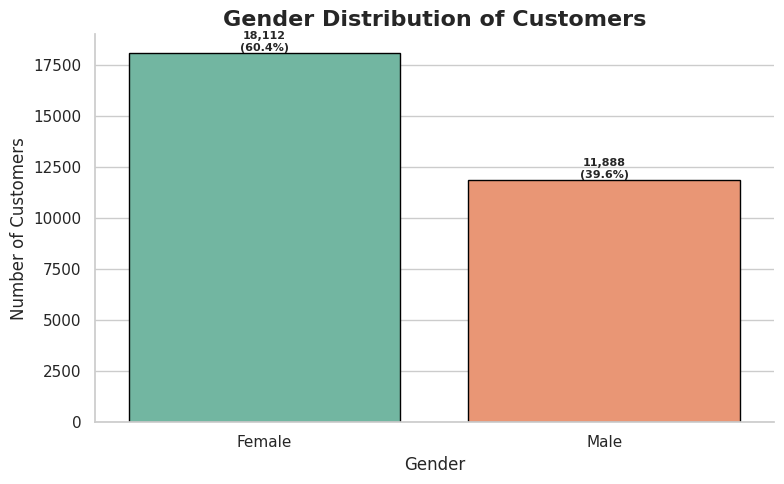

In [35]:
sns.set_theme(style="whitegrid")
gender_counts = credit_df["gender"].value_counts()
total = len(credit_df)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=credit_df,
    x="gender",
    order=gender_counts.index,
    palette="Set2",
    edgecolor="black"
)

for p in ax.patches:
  count = int(p.get_height())
  percentage = (count / total) * 100

  ax.annotate(
      f'{count:,}\n({percentage:.1f}%)',
       (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
  )


plt.title("Gender Distribution of Customers", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()


### Business Question

What is the age distribution of customers?

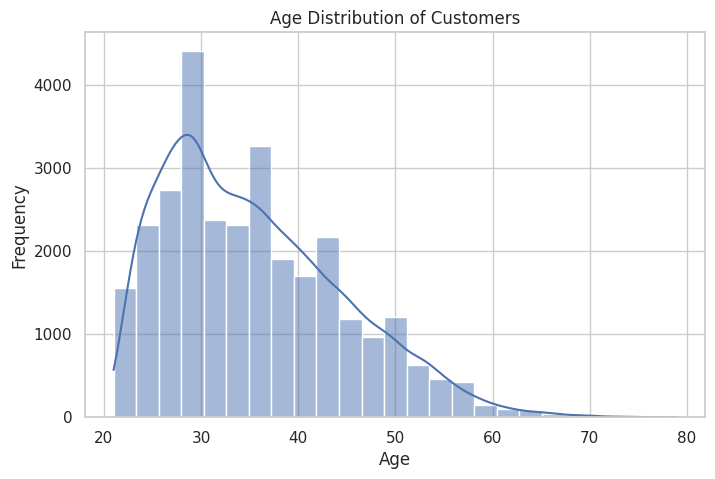

In [36]:
plt.figure(figsize = (8,5))
sns.histplot(
    credit_df["age"],
    bins=  25,
    kde= True
)
plt.title("Age Distribution of Customers")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Insight

- Most customers belong to the working-age population.
- Younger and middle-aged customers appear to dominate the customer base.
- This information helps identify the primary target demographic.

### Business Question

Which age group has the largest number of customers?

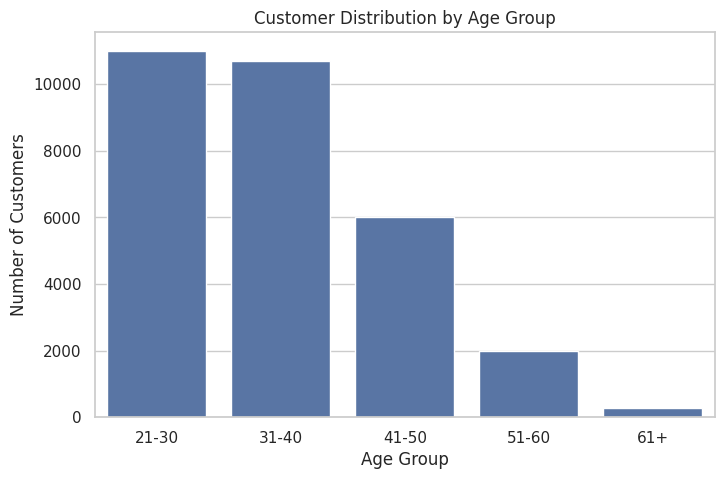

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=credit_df,
    x="Age_Group",
    order=credit_df["Age_Group"].value_counts().index
)

plt.title("Customer Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Number of Customers")

plt.show()

### Business Question

What is the educational background of customers?

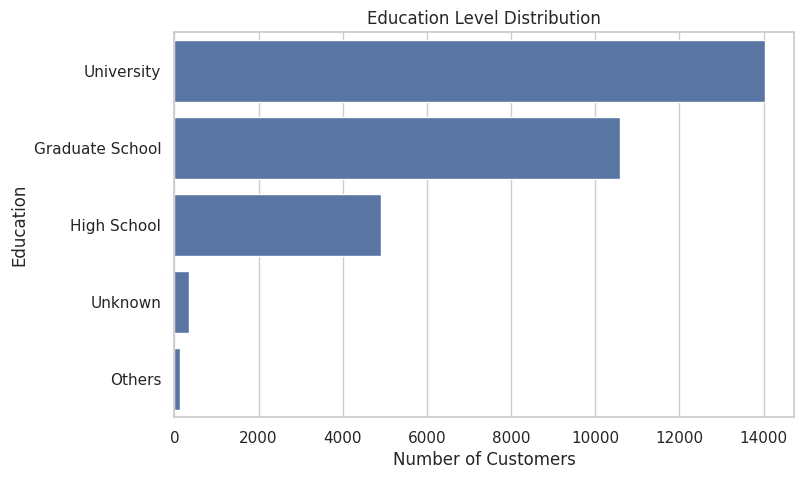

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=credit_df,
    y="education",
    order=credit_df["education"].value_counts().index
)

plt.title("Education Level Distribution")

plt.xlabel("Number of Customers")

plt.ylabel("Education")

plt.show()

### Business Question

How are customers distributed by marital status?

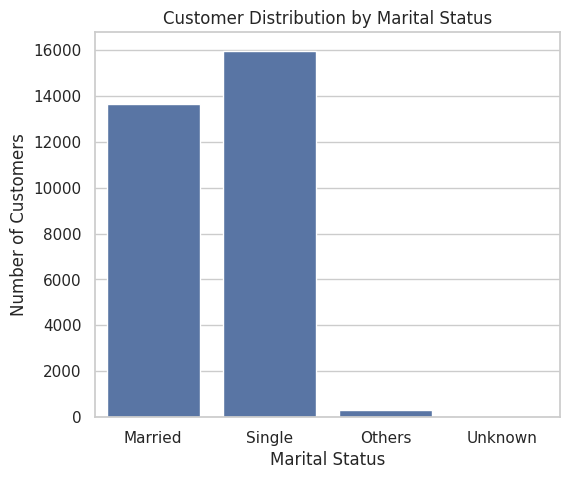

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=credit_df,
    x="marital_status"
)

plt.title("Customer Distribution by Marital Status")

plt.xlabel("Marital Status")

plt.ylabel("Number of Customers")

plt.show()

## 2) Credit Behaviour Analysis

### Objective
This section analyzes customers' credit usage patterns and financial behavior.

The analysis focuses on answering the following business questions:

- What is the distribution of customer credit limits?
- How much credit are customers utilizing?
- How much do customers owe on average?
- How much are customers paying?
- Is there a relationship between credit limit and outstanding bills?

### Business Question

How are credit limits distributed among customers?

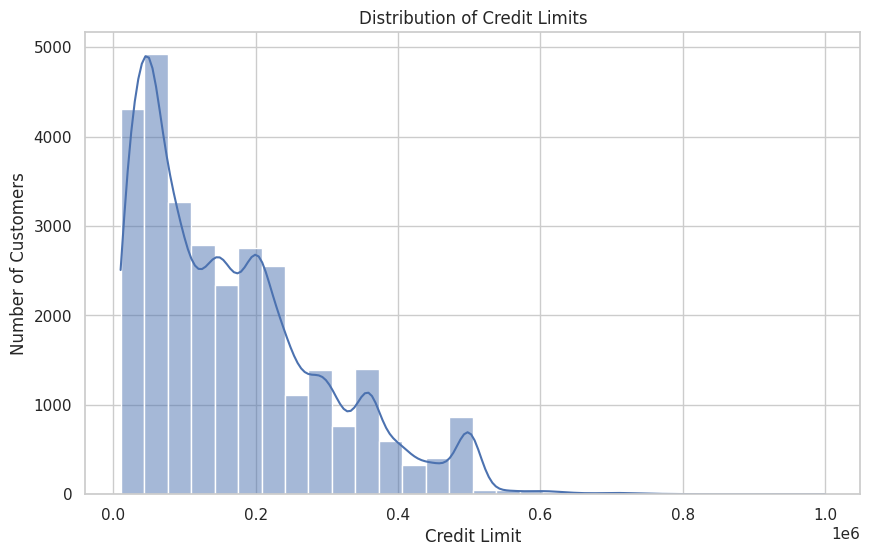

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=credit_df,
    x="credit_limit",
    bins=30,
    kde=True
)

plt.title("Distribution of Credit Limits")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

### Business Question

How efficiently are customers utilizing their available credit?

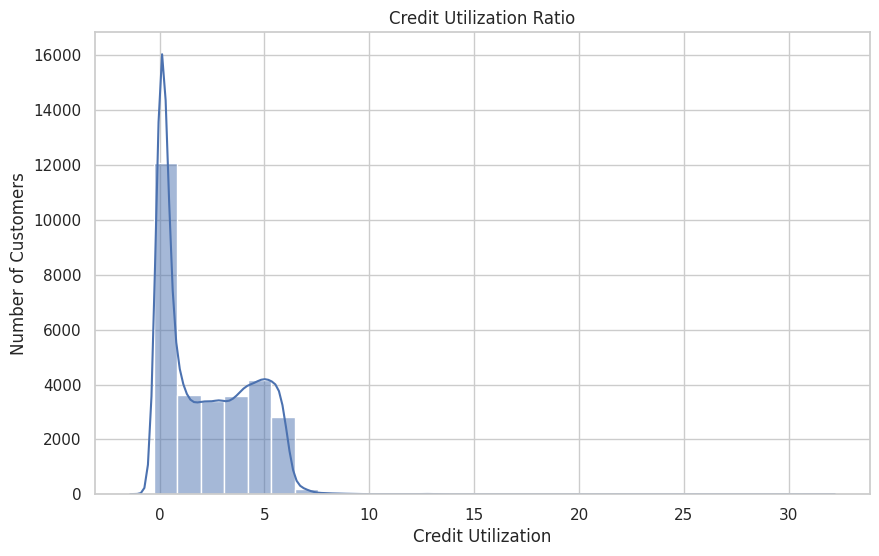

In [41]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=credit_df,
    x="Credit_Utilization",
    bins=30,
    kde=True
)

plt.title("Credit Utilization Ratio")
plt.xlabel("Credit Utilization")
plt.ylabel("Number of Customers")

plt.show()

### Business Question

Who are the customers with the highest approved credit limits?

In [42]:
top_credit = (
    credit_df
    .sort_values("credit_limit", ascending=False)
    .head(10)
)

top_credit[["customer_id","credit_limit"]]

,customer_id,credit_limit
2197,2198,1000000.0
14919,14920,800000.0
18006,18007,800000.0
24320,24321,780000.0
28715,28716,780000.0
21375,21376,760000.0
10089,10090,750000.0
3733,3734,750000.0
13186,13187,750000.0
4603,4604,750000.0


### Business Question

Does credit limit allocation differ by gender?

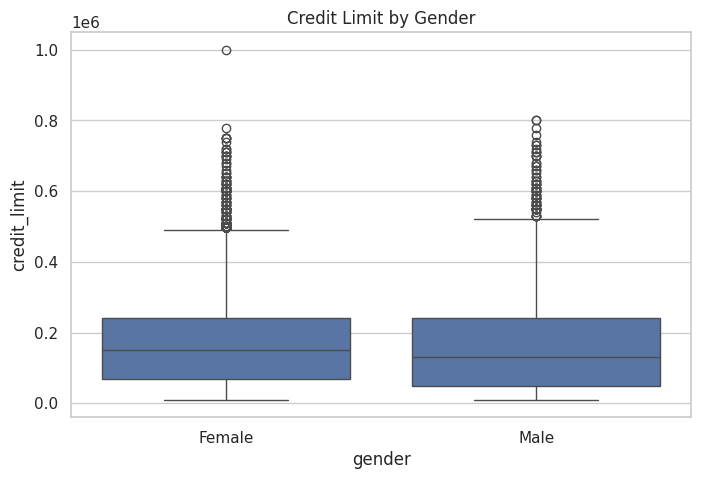

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="gender",
    y="credit_limit"
)

plt.title("Credit Limit by Gender")

plt.show()

### Business Question

What is the distribution of customers' average monthly bill amounts?

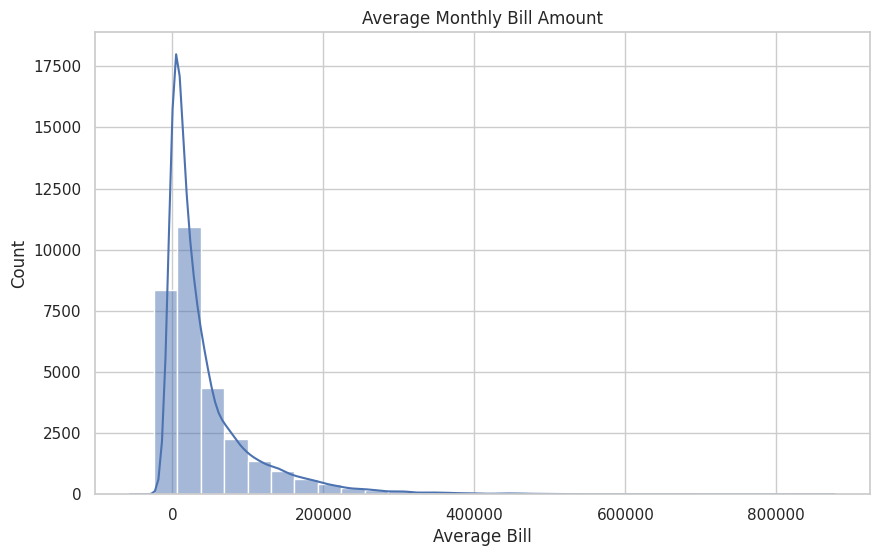

In [44]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=credit_df,
    x="Average_Bill",
    bins=30,
    kde=True
)

plt.title("Average Monthly Bill Amount")

plt.xlabel("Average Bill")

plt.show()

### Business Question

How much do customers typically repay each month?

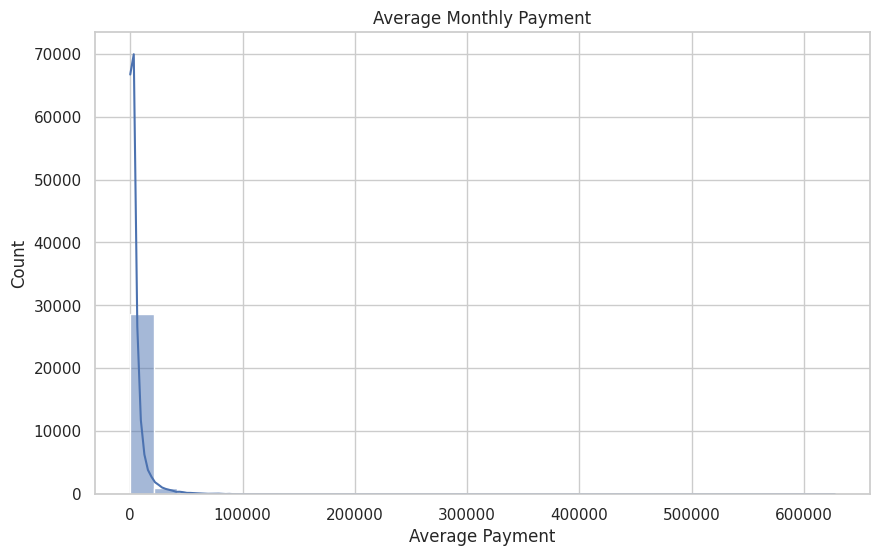

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=credit_df,
    x="Average_Payment",
    bins=30,
    kde=True
)

plt.title("Average Monthly Payment")

plt.xlabel("Average Payment")

plt.show()

### Business Question

Is there a relationship between outstanding bills and customer payments?

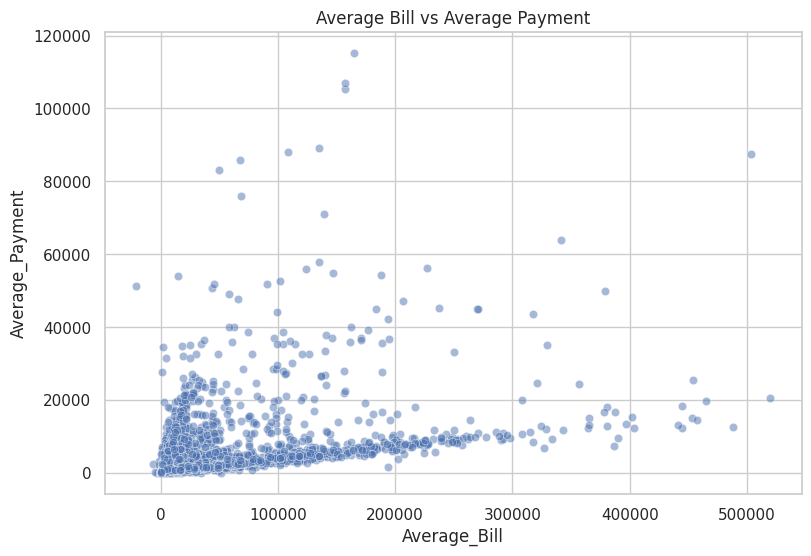

In [46]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=credit_df.sample(3000),
    x="Average_Bill",
    y="Average_Payment",
    alpha=0.5
)

plt.title("Average Bill vs Average Payment")

plt.show()

### Business Question

Do customers with higher credit limits also carry higher outstanding bills?

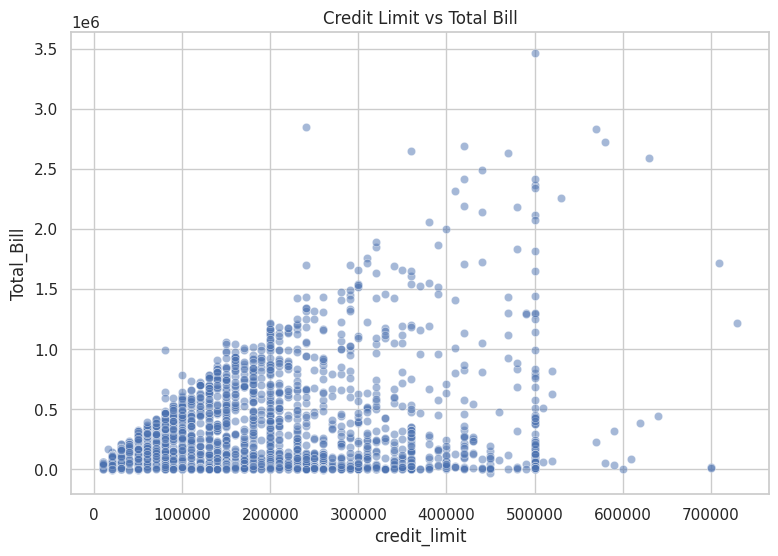

In [47]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=credit_df.sample(3000),
    x="credit_limit",
    y="Total_Bill",
    alpha=0.5
)

plt.title("Credit Limit vs Total Bill")

plt.show()

In [48]:
credit_df[
[
    "credit_limit",
    "Average_Bill",
    "Average_Payment",
    "Credit_Utilization"
]
].describe().T

,count,mean,std,min,25%,50%,75%,max
credit_limit,30000.0,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1000000.000000
Average_Bill,30000.0,44976.945200,63260.721860,-56043.166667,4781.333333,21051.833333,57104.416667,877313.833333
Average_Payment,30000.0,5275.232094,10137.946323,0.000000,1113.291667,2397.166667,5583.916667,627344.333333
Credit_Utilization,30000.0,2.238279,2.111341,-1.400000,0.180000,1.710000,4.130000,32.190000


## 3) Default Risk Analysis

### Objective

This section analyzes customer default behavior to identify factors associated with higher credit risk.

The analysis aims to answer the following business questions:

- What is the overall customer default rate?
- Which customer segments have the highest default rate?
- Does gender influence default behavior?
- Does age influence default behavior?
- Does education level affect default rates?
- Do customers with high credit utilization default more frequently?
- How is customer risk category related to default?

The insights obtained from this analysis can support risk assessment, customer segmentation, and credit policy decisions.

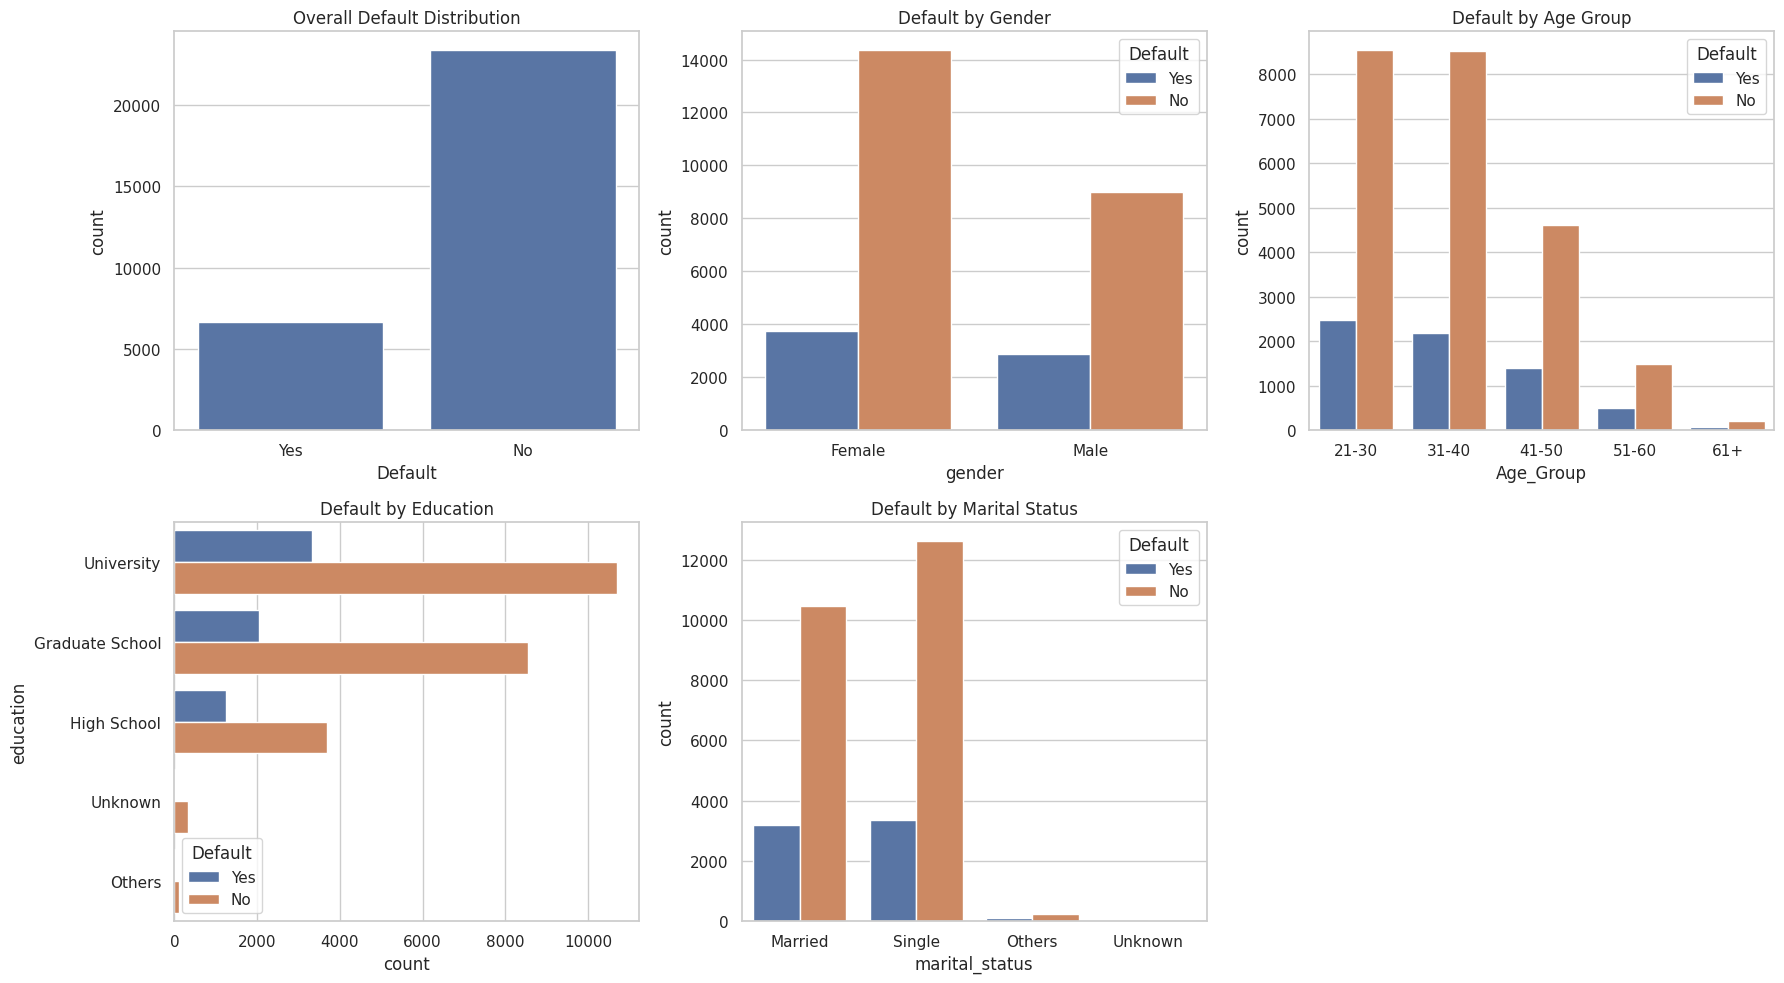

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall Default Distribution
sns.countplot(
    data=credit_df,
    x="Default",
    ax=axes[0,0]
)

axes[0,0].set_title("Overall Default Distribution")


# 2. Gender
sns.countplot(
    data=credit_df,
    x="gender",
    hue="Default",
    ax=axes[0,1]
)

axes[0,1].set_title("Default by Gender")


# 3. Age Group
sns.countplot(
    data=credit_df,
    x="Age_Group",
    hue="Default",
    ax=axes[0,2]
)

axes[0,2].set_title("Default by Age Group")


# 4. Education
sns.countplot(
    data=credit_df,
    y="education",
    hue="Default",
    ax=axes[1,0]
)

axes[1,0].set_title("Default by Education")


# 5. Marital Status
sns.countplot(
    data=credit_df,
    x="marital_status",
    hue="Default",
    ax=axes[1,1]
)

axes[1,1].set_title("Default by Marital Status")


# Remove the unused subplot
fig.delaxes(axes[1,2])

plt.tight_layout()

plt.show()

### Business Question

Do customers with higher credit utilization default more frequently?

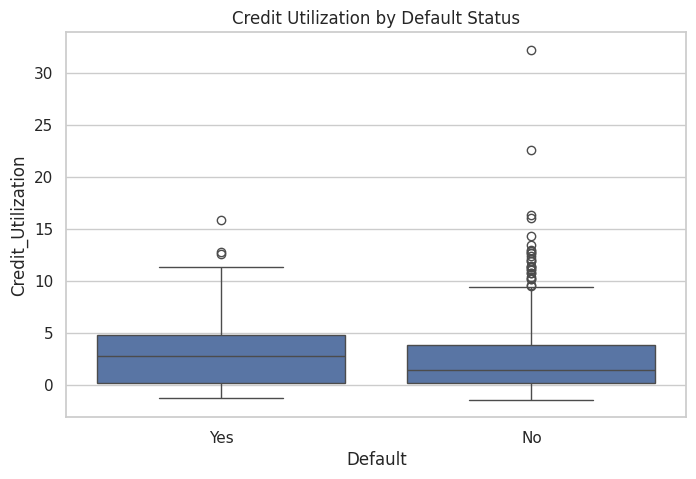

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Default",
    y="Credit_Utilization"
)

plt.title("Credit Utilization by Default Status")

plt.show()

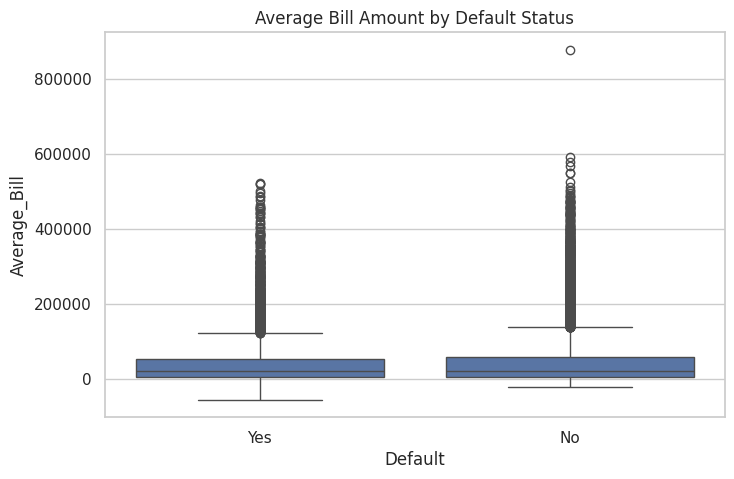

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Default",
    y="Average_Bill"
)

plt.title("Average Bill Amount by Default Status")

plt.show()

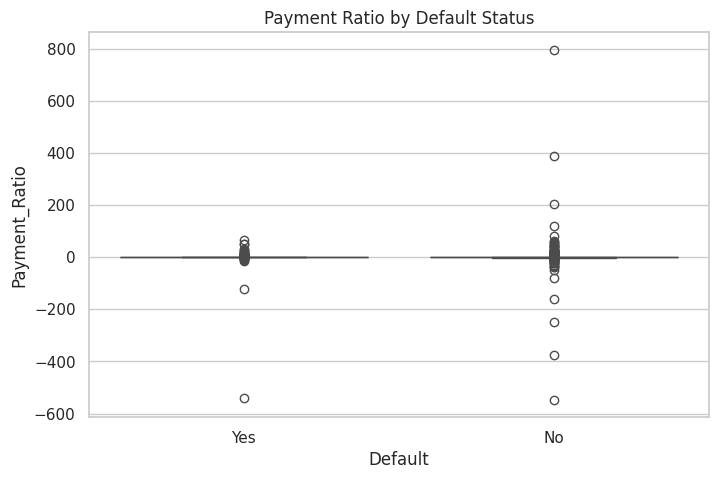

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=credit_df,
    x="Default",
    y="Payment_Ratio"
)

plt.title("Payment Ratio by Default Status")

plt.show()

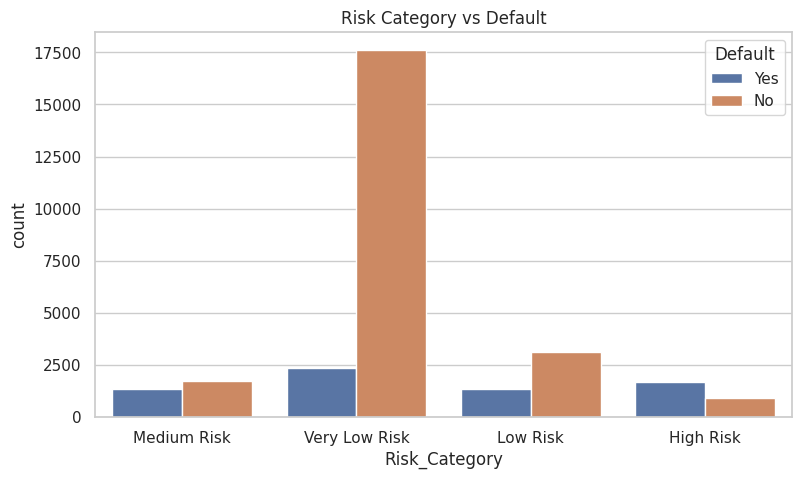

In [53]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=credit_df,
    x="Risk_Category",
    hue="Default"
)

plt.title("Risk Category vs Default")

plt.show()

### Business Question

Which numerical variables are most strongly correlated?

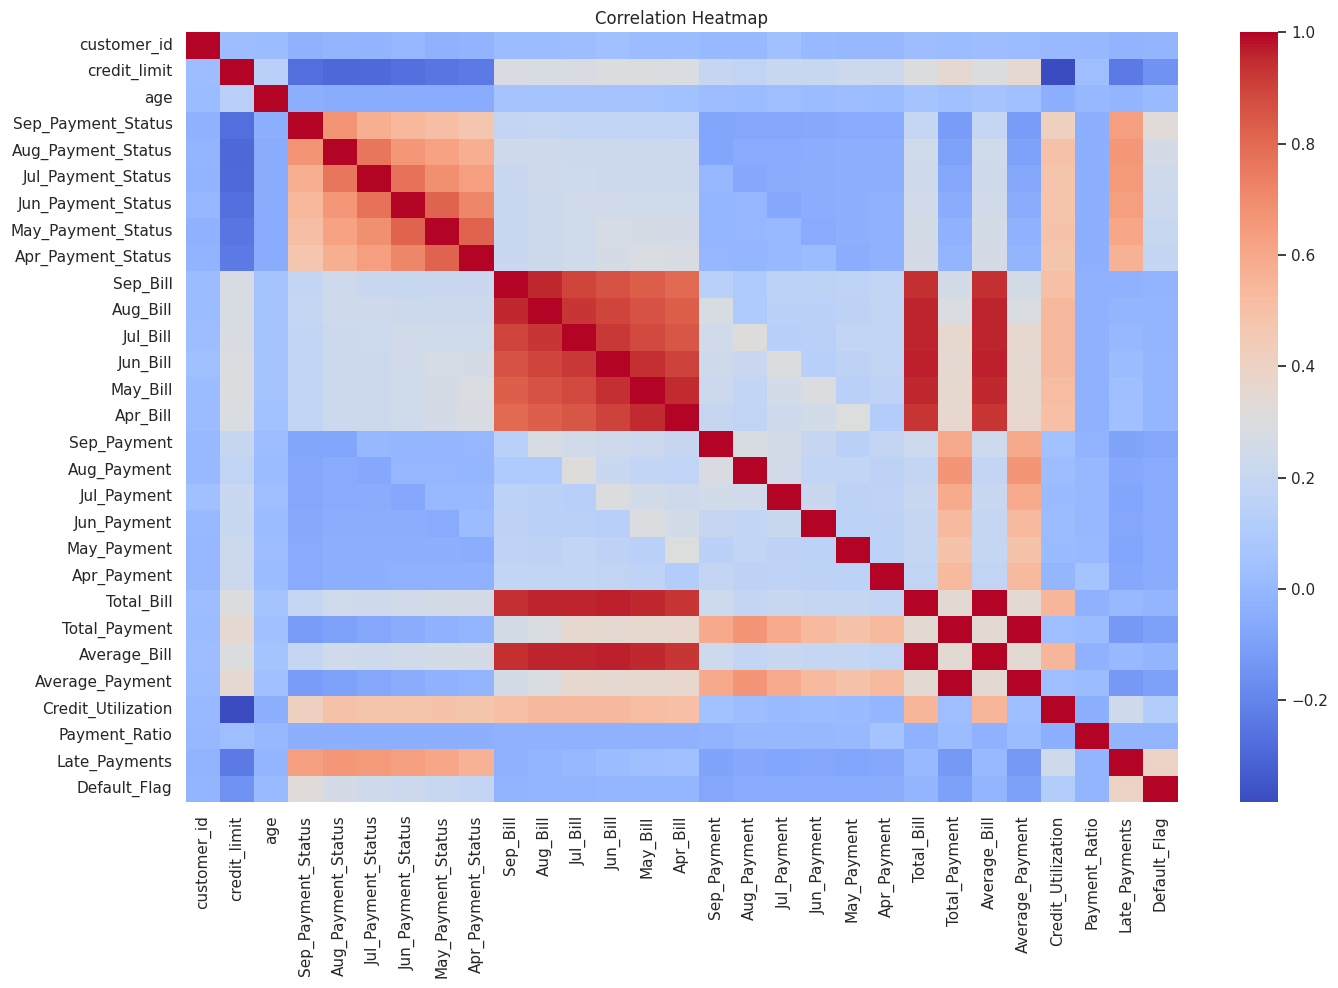

In [54]:
plt.figure(figsize=(16,10))

numeric_df = credit_df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

# Business KPI Summary

The following KPIs provide a high-level overview of the customer portfolio and will be used in the Power BI dashboard.

These metrics summarize customer demographics, credit behavior, payment behavior, and default risk.

In [55]:
# Business KPI Summary

kpis = {

    "Total Customers":
        credit_df["customer_id"].nunique(),

    "Total Defaulters":
        (credit_df["Default"] == "Yes").sum(),

    "Default Rate (%)":
        round((credit_df["Default"] == "Yes").mean() * 100, 2),

    "Average Age":
        round(credit_df["age"].mean(), 1),

    "Average Credit Limit":
        round(credit_df["credit_limit"].mean(), 2),

    "Average Credit Utilization":
        round(credit_df["Credit_Utilization"].mean(), 2),

    "Average Payment Ratio":
        round(credit_df["Payment_Ratio"].mean(), 2),

    "Average Monthly Bill":
        round(credit_df["Average_Bill"].mean(), 2),

    "Average Monthly Payment":
        round(credit_df["Average_Payment"].mean(), 2),

    "High Risk Customers":
        (credit_df["Risk_Category"] == "High Risk").sum()

}

kpi_summary = pd.DataFrame(
    kpis.items(),
    columns=["KPI", "Value"]
)

kpi_summary

,KPI,Value
0,Total Customers,30000.00
1,Total Defaulters,6636.00
2,Default Rate (%),22.12
3,Average Age,35.50
4,Average Credit Limit,167484.32
5,Average Credit Utilization,2.24
6,Average Payment Ratio,inf
7,Average Monthly Bill,44976.95
8,Average Monthly Payment,5275.23
9,High Risk Customers,2590.00
